In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch, resample


def read_mono_normalized(path):
    fs, x = wavfile.read(path)
    x = x.astype(np.float64)

    # Convert stereo to mono
    if x.ndim == 2:
        x = x.mean(axis=1)

    # Normalize amplitude to [-1, 1]
    max_abs = np.max(np.abs(x))
    if max_abs > 0:
        x /= max_abs
    return fs, x




In [21]:
def compare_multiple_spectra(
    files, labels=None,
    n_fft=65536, use_welch=False, target_fs=None,
    freq_range=None, log_scale=True
):
    """
    Compare spectra of multiple WAV files.

    Args:
        files : list of file paths
        labels : list of legend labels (same length as files)
        n_fft : FFT size
        use_welch : True for PSD, False for magnitude spectrum
        target_fs : resample all to this rate (e.g., 16000)
        freq_range : (fmin, fmax) for frequency axis
        log_scale : True -> semilogx, False -> linear
    """
    if labels is None:
        labels = [f"File {i+1}" for i in range(len(files))]

    plt.figure(figsize=(9, 5))

    for file, label in zip(files, labels):
        fs, x = read_mono_normalized(file)

        # Optional resampling to a target Fs
        if target_fs is not None and fs != target_fs:
            N = int(len(x) * target_fs / fs)
            x = resample(x, N)
            fs = target_fs

        if use_welch:
            # Welch PSD
            f, Pxx = welch(x, fs=fs, nperseg=4096, noverlap=2048, nfft=n_fft)
            Pxx_db = 10 * np.log10(Pxx + 1e-12)
        else:
            # FFT magnitude spectrum
            N = len(x)
            if N > n_fft:
                start = (N - n_fft) // 2
                x = x[start:start + n_fft]
            w = np.hanning(len(x))
            X = np.fft.rfft(x * w, n=n_fft)
            f = np.fft.rfftfreq(n_fft, d=1/fs)
            scale = np.sum(w) / 2.0
            M_db = 20 * np.log10(np.abs(X) / (scale + 1e-12) + 1e-12)
            Pxx_db = M_db

        # Plot
        if log_scale:
            plt.semilogx(f, Pxx_db, label=label)
        else:
            plt.plot(f, Pxx_db, label=label)

    # Axis setup
    plt.xlabel("Frequency (Hz, log scale)" if log_scale else "Frequency (Hz)")
    plt.ylabel("PSD (dB/Hz)" if use_welch else "Magnitude (dBFS)")
    plt.title("Spectral Comparison" + (" (Welch)" if use_welch else " (FFT)"))
    plt.grid(True, which='both', linewidth=0.5)

    if freq_range is not None:
        plt.xlim(freq_range)

    plt.legend()
    plt.tight_layout()
    plt.show()


# === Example usage ===
# Compare 3 audio files between 100–1000 Hz
# compare_multiple_spectra(
#     files=["voice_a.wav", "voice_b.wav", "voice_c.wav"],
#     labels=["Male", "Female", "Child"],
#     use_welch=False, target_fs=16000,
#     freq_range=(100, 1000), log_scale=True
# )


/tmp/ipykernel_47098/4121354298.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read(path)


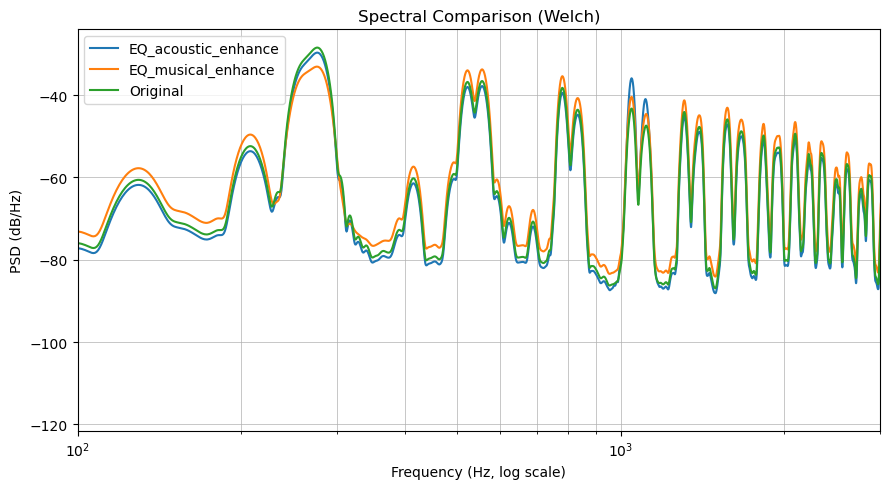

In [27]:
# Example:
# === Example usage ===
# You can modify the labels and range below:
compare_multiple_spectra(
    files=["stimulus/Cello_C3CSharp3_EQ_acoustic_enhance.wav","stimulus/Cello_C3CSharp3_EQ_musical_enhance.wav", "stimulus/Cello_C3CSharp3.wav"],
    labels=["EQ_acoustic_enhance", "EQ_musical_enhance", "Original"],
    use_welch=True, target_fs=48000,
    freq_range=(100, 3000), log_scale=True
)

#compare_spectra("stimulus/Cello_C3ASharp3_EQ_acoustic_enhance.wav", "stimulus/Cello_C3ASharp3.wav", n_fft=65536, use_welch=True, target_fs=2000)